In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_points(filename):
    #df = pd.read_csv(filename, sep='\t', header=2)
    df = pd.read_csv(filename, header=2)
    df = df.rename(columns={"X (project units)": "X", "Y (project units)": "Y", "Z (project units)": "Z (um)", "Z Precision": "Z Precision (um)"})
    df = df[df.Id>12]
    df[['Z (um)','Z Precision (um)']] = df[['Z (um)','Z Precision (um)']]*1000000
    return df

In [3]:
def plot_points(df, meas, min, max, fname):
    plt.figure(figsize=(10,6))
    ax = plt.gca()
    ax.set_aspect('equal')
    plt.scatter(x=df['X'], y=df['Y'], c=df[meas], cmap='jet', s=200, vmin=min, vmax=max)
    plt.grid()
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.xlim(-1.4, 1.6)
    cbar = plt.colorbar()
    cbar.set_label(meas)
    plt.savefig(fname)
    plt.show()

In [33]:
def plot_hist(df, meas, b, x_min, x_max, width, fname):
    plt.figure(figsize=(10,6))
    ax = plt.gca()
    plt.hist(x=df[meas], bins = b,range=(x_min, x_max), rwidth=width)
    plt.xlabel(meas)
    plt.ylabel('Counts')
    plt.savefig(fname)
    plt.show()

In [4]:
Set_Warm = load_points("BA_fff_WarmCalibration.txt")
Set_Cold = load_points("BA_fff_ColdCalibration.txt")
Set_Field = load_points("BA_fff_FieldCalibration.txt")

In [5]:
Set_Warm.describe()

,Id,X,Y,Z (um),X Precision,Y Precision,Z Precision (um),Tightness (percent),Tightness (project units),Angle (deg.),RMS Residual (pixels),Largest Residual (pixels),Photo Largest Residual,#Constraints,Target Code,Color (R),Color (G),Color (B)
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.0,0.0,87.0,87.0,87.0
mean,3698.977011,-0.014736,0.080984,250.011494,0.000087,0.000088,108.333333,0.049832,0.001921,89.896548,1.068377,2.679645,38.816092,0.0,NaN,255.0,255.0,255.0
std,1283.252590,0.811110,0.525803,336.149382,0.000018,0.000019,23.178612,0.010806,0.000416,0.153583,0.384412,0.971619,20.046184,0.0,NaN,0.0,0.0,0.0
min,1303.000000,-1.297963,-0.669701,-484.000000,0.000064,0.000071,93.000000,0.027110,0.001045,89.131555,0.607871,1.389262,2.000000,0.0,NaN,255.0,255.0,255.0
25%,3182.000000,-0.730130,-0.405127,-12.500000,0.000077,0.000082,97.000000,0.042776,0.001649,89.884902,0.777451,1.927789,29.000000,0.0,NaN,255.0,255.0,255.0
50%,4394.000000,-0.015314,0.024038,265.000000,0.000087,0.000086,104.000000,0.049121,0.001893,89.945292,0.958664,2.544146,43.000000,0.0,NaN,255.0,255.0,255.0
75%,4816.500000,0.714551,0.474414,546.500000,0.000093,0.000090,112.500000,0.056979,0.002196,89.976795,1.278721,3.070717,43.500000,0.0,NaN,255.0,255.0,255.0
max,4965.000000,1.340946,1.052907,906.000000,0.000220,0.000245,292.000000,0.078799,0.003037,89.998192,2.447814,5.811207,83.000000,0.0,NaN,255.0,255.0,255.0


In [6]:
Set_Cold.describe()

,Id,X,Y,Z (um),X Precision,Y Precision,Z Precision (um),Tightness (percent),Tightness (project units),Angle (deg.),RMS Residual (pixels),Largest Residual (pixels),Photo Largest Residual,#Constraints,Target Code,Color (R),Color (G),Color (B)
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.0,0.0,87.0,87.0,87.0
mean,3698.977011,-0.014675,0.081027,503.471264,0.000079,0.000080,98.321839,0.046740,0.001801,89.897666,0.987053,2.604490,42.218391,0.0,NaN,255.0,255.0,255.0
std,1283.252590,0.811495,0.525878,426.710561,0.000016,0.000017,21.012452,0.009384,0.000362,0.152221,0.342314,1.025742,17.538944,0.0,NaN,0.0,0.0,0.0
min,1303.000000,-1.298098,-0.670039,-296.000000,0.000058,0.000064,84.000000,0.022655,0.000873,89.141397,0.567642,1.288730,4.000000,0.0,NaN,255.0,255.0,255.0
25%,3182.000000,-0.730525,-0.405117,152.000000,0.000070,0.000074,88.000000,0.041613,0.001603,89.895094,0.758310,1.902366,39.000000,0.0,NaN,255.0,255.0,255.0
50%,4394.000000,-0.015398,0.024409,543.000000,0.000079,0.000078,94.000000,0.045621,0.001758,89.945158,0.836618,2.387813,43.000000,0.0,NaN,255.0,255.0,255.0
75%,4816.500000,0.715153,0.474684,813.000000,0.000084,0.000082,102.000000,0.051514,0.001985,89.976348,1.185034,3.016911,47.500000,0.0,NaN,255.0,255.0,255.0
max,4965.000000,1.341381,1.053166,1410.000000,0.000200,0.000223,265.000000,0.069375,0.002674,89.999951,2.117270,5.756086,73.000000,0.0,NaN,255.0,255.0,255.0


In [7]:
Set_Field.describe()

,Id,X,Y,Z (um),X Precision,Y Precision,Z Precision (um),Tightness (percent),Tightness (project units),Angle (deg.),RMS Residual (pixels),Largest Residual (pixels),Photo Largest Residual,#Constraints,Target Code,Color (R),Color (G),Color (B)
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.0,0.0,87.0,87.0,87.0
mean,3698.977011,-0.014742,0.081011,615.793103,0.000073,0.000073,93.344828,0.042529,0.001639,89.897998,0.894999,2.302773,37.942529,0.0,NaN,255.0,255.0,255.0
std,1283.252590,0.811280,0.525826,503.724042,0.000015,0.000016,19.236489,0.009411,0.000363,0.152557,0.306533,0.820214,20.062899,0.0,NaN,0.0,0.0,0.0
min,1303.000000,-1.298041,-0.669867,-202.000000,0.000053,0.000059,77.000000,0.023275,0.000897,89.089544,0.485658,1.062893,4.000000,0.0,NaN,255.0,255.0,255.0
25%,3182.000000,-0.730430,-0.405106,192.500000,0.000065,0.000068,84.000000,0.035882,0.001383,89.889452,0.709452,1.708036,25.000000,0.0,NaN,255.0,255.0,255.0
50%,4394.000000,-0.015221,0.024204,616.000000,0.000074,0.000072,89.000000,0.042005,0.001619,89.944638,0.777782,2.124257,43.000000,0.0,NaN,255.0,255.0,255.0
75%,4816.500000,0.714872,0.474602,967.500000,0.000077,0.000075,96.000000,0.049536,0.001910,89.972757,1.021866,2.651384,43.000000,0.0,NaN,255.0,255.0,255.0
max,4965.000000,1.340910,1.052957,1816.000000,0.000183,0.000203,242.000000,0.064888,0.002501,89.999277,1.993583,4.813014,73.000000,0.0,NaN,255.0,255.0,255.0


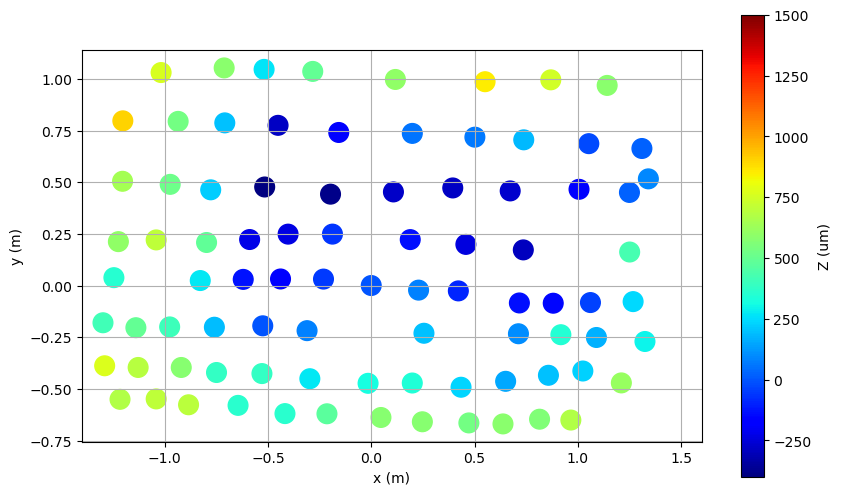

In [8]:
plot_points(Set_Warm, "Z (um)", -400, 1500,'WarmCal_Mirror_Height.png') 

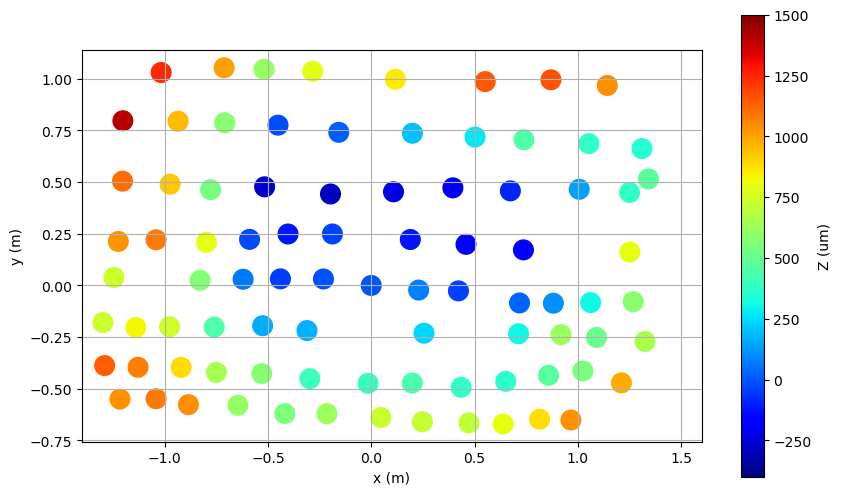

In [9]:
plot_points(Set_Cold, "Z (um)", -400, 1500,'ColdCal_Mirror_Height.png')

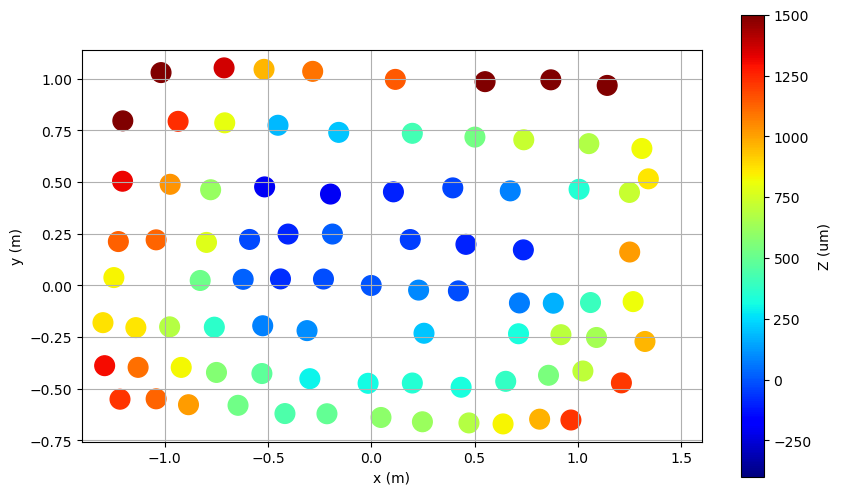

In [10]:
plot_points(Set_Field, "Z (um)", -400, 1500,'FieldCal_Mirror_Height.png')

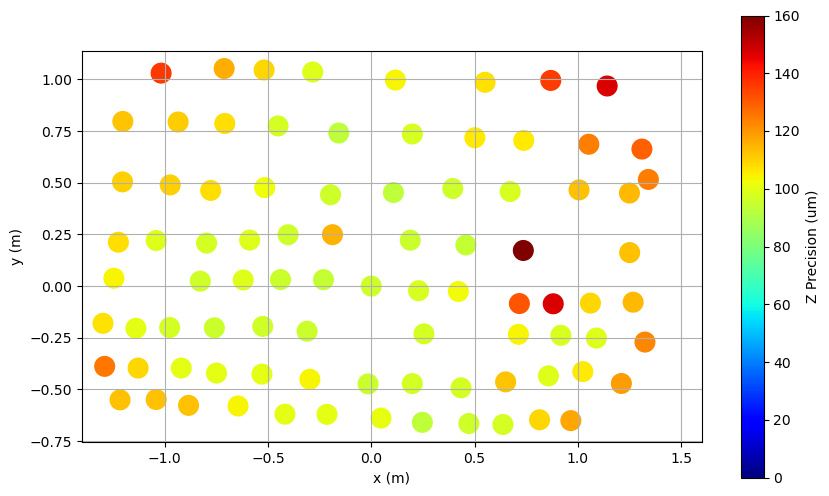

In [11]:
plot_points(Set_Warm, "Z Precision (um)", 0, 160,'WarmCal_Height_Precision.png')

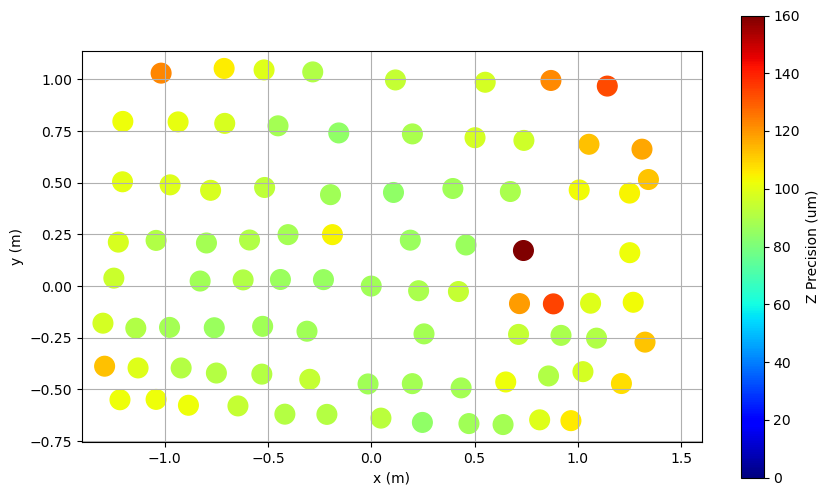

In [12]:
plot_points(Set_Cold, "Z Precision (um)", 0, 160,'ColdCal_Height_Precision.png')

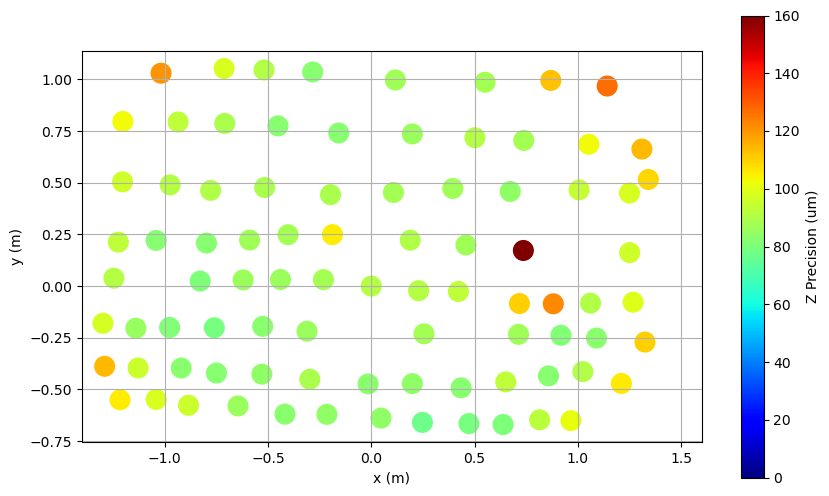

In [13]:
plot_points(Set_Field, "Z Precision (um)", 0, 160,'FieldCal_Height_Precision.png')

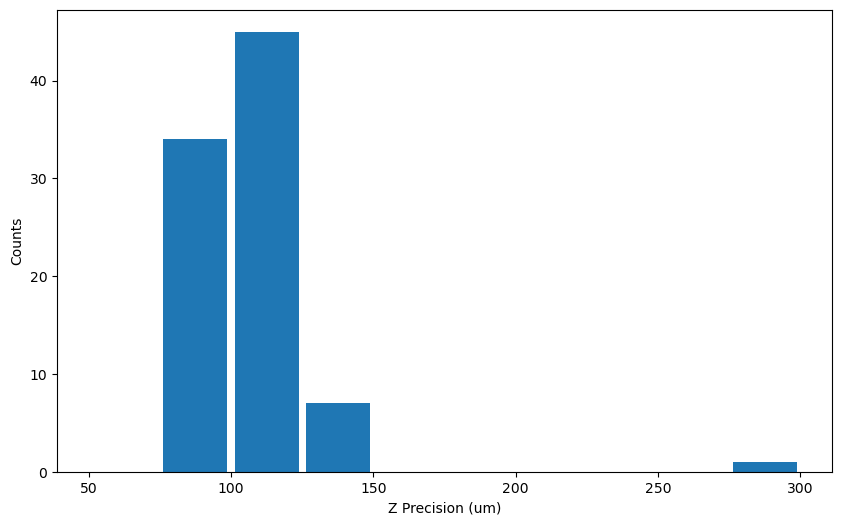

In [41]:
plot_hist(Set_Warm, "Z Precision (um)", 10, 50, 300, 0.9, "WarmCal_Precision_Histogram.png")

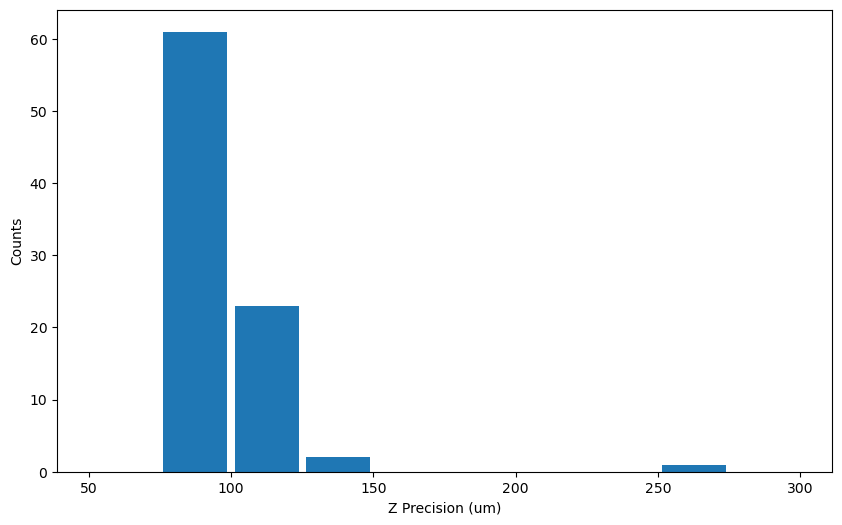

In [42]:
plot_hist(Set_Cold, "Z Precision (um)", 10, 50, 300, 0.9, "ColdCal_Precision_Histogram.png")

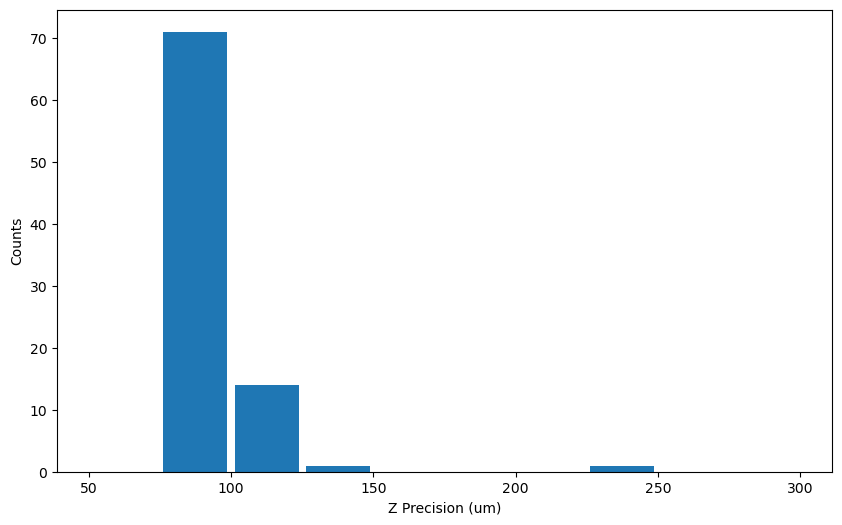

In [43]:
plot_hist(Set_Field, "Z Precision (um)", 10, 50, 300, 0.9, "FieldCal_Precision_Histogram.png")